In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
choice = 0  #start from 0
devices = ['sg13_lv_nmos', 'sg13_lv_pmos', 'sg13_lv_nmos_rf', 'sg13_lv_pmos_rf', 'sg13_hv_nmos', 'sg13_hv_pmos', 'sg13_hv_nmos_rf', 'sg13_hv_pmos_rf']

# widths used for characterization
w = np.array([5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0])

In [26]:
# read ngspice data
df_raw = pd.read_csv('./simulations/techsweep_'+devices[choice]+'.txt', sep='\s+')
par_names = df_raw.columns.to_list()
fet_name = par_names[1].split('[')[0]

# remove unwanted columns and rename for readability
df = df_raw.drop(['g', 'g.1', 'b', 'd', 'n'], axis=1)
df = df.apply(pd.to_numeric)
df.columns = df.columns.str.replace(fet_name, '')
df.columns = df.columns.str.replace(fet_name[1:], '')
df.columns = df.columns.str.replace('[dc]', '')
df.columns = df.columns.str.replace('onoise..', 'n')
df.columns = df.columns.str.removeprefix('@')
df.columns = df.columns.str.removeprefix('[')
df.columns = df.columns.str.removesuffix(']')
df

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\3922770924.py:2: SyntaxWarning: invalid escape sequence '\s'
  df_raw = pd.read_csv('./simulations/techsweep_'+devices[choice]+'.txt', sep='\s+')


,cdd,cgb,cgd,cgdol,cgg,cgs,cgsol,cjd,cjs,css,...,gm,gmb,ids,l,sfl,sid,vth,vb,vd,vg
0,1.486000e-22,1.607000e-17,6.050000e-21,8.064000e-17,1.608000e-17,6.050000e-21,8.064000e-17,7.702000e-17,7.702000e-17,1.486000e-22,...,-1.129000e-15,-1.470000e-37,0.000000e+00,1.300000e-07,0.000000e+00,1.047000e-30,0.4371,0.0,0.000,0.0
1,4.649000e-23,1.364000e-17,2.956000e-21,8.064000e-17,1.365000e-17,2.956000e-21,8.064000e-17,7.116000e-17,7.116000e-17,4.649000e-23,...,-1.129000e-15,-0.000000e+00,0.000000e+00,1.300000e-07,0.000000e+00,3.261000e-31,0.4610,-0.2,0.000,0.0
2,1.752000e-23,1.209000e-17,1.699000e-21,8.064000e-17,1.209000e-17,1.699000e-21,8.064000e-17,6.688000e-17,6.688000e-17,1.752000e-23,...,-1.129000e-15,-0.000000e+00,0.000000e+00,1.300000e-07,0.000000e+00,1.223000e-31,0.4825,-0.4,0.000,0.0
3,6.122000e-23,1.607000e-17,2.452000e-21,8.043000e-17,1.608000e-17,9.239000e-21,8.064000e-17,7.616000e-17,7.702000e-17,1.506000e-22,...,2.864000e-11,6.845000e-12,1.054000e-12,1.300000e-07,4.765000e-30,7.550000e-31,0.4371,0.0,0.025,0.0
4,1.915000e-23,1.364000e-17,1.205000e-21,8.043000e-17,1.365000e-17,4.559000e-21,8.064000e-17,7.055000e-17,7.116000e-17,4.711000e-23,...,9.312000e-12,1.737000e-12,3.283000e-13,1.300000e-07,4.899000e-31,2.351000e-31,0.4610,-0.2,0.025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129649,3.275000e-16,3.017000e-15,3.932000e-16,1.820000e-15,7.970000e-14,7.629000e-14,1.933000e-15,8.530000e-16,1.111000e-15,4.866000e-14,...,2.817000e-04,3.554000e-05,1.520000e-04,3.000000e-06,4.101000e-18,4.167000e-24,0.2368,-0.2,1.175,1.2
129650,3.091000e-16,2.940000e-15,3.726000e-16,1.820000e-15,7.943000e-14,7.612000e-14,1.933000e-15,8.286000e-16,1.042000e-15,4.833000e-14,...,2.771000e-04,3.251000e-05,1.452000e-04,3.000000e-06,3.899000e-18,4.051000e-24,0.2578,-0.4,1.175,1.2
129651,3.261000e-16,3.092000e-15,3.890000e-16,1.816000e-15,7.996000e-14,7.647000e-14,1.933000e-15,8.771000e-16,1.206000e-15,4.906000e-14,...,2.869000e-04,3.924000e-05,1.597000e-04,3.000000e-06,4.328000e-18,4.300000e-24,0.2139,0.0,1.200,1.2
129652,3.078000e-16,3.019000e-15,3.691000e-16,1.816000e-15,7.967000e-14,7.628000e-14,1.933000e-15,8.498000e-16,1.111000e-15,4.866000e-14,...,2.821000e-04,3.558000e-05,1.522000e-04,3.000000e-06,4.108000e-18,4.171000e-24,0.2368,-0.2,1.200,1.2


In [27]:
# sweep variable vectors
l =   np.unique(df['l'])
vgs = np.unique(df['vg'])
vds = np.unique(df['vd'])
vsb = np.unique(-df['vb'])

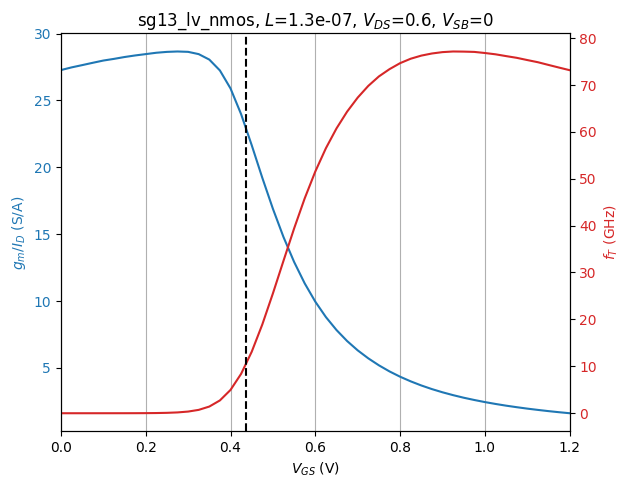

In [28]:
# plot gm/ID and fT versus gate bias
L1 = min(l); VDS1=np.max(vds)/2; VSB1=0
df1 = df.loc[(df['l'] == L1) & (df['vd'] == VDS1)& (df['vb'] == -VSB1)]
gm_id1 = df1['gm'].values/df1['ids'].values
cgg1 = df1['cgg'].values + df1['cgsol'].values + df1['cgdol'].values
ft1 = df1['gm'].values/cgg1/2/np.pi
fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id1, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft1/1e9, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, max(vgs))
plt.axvline(x = df1['vth'].values[0], color='k', linestyle='--')
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\835228120.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$f_T\cdot g_m/I_D$ (GHz-S/A)')


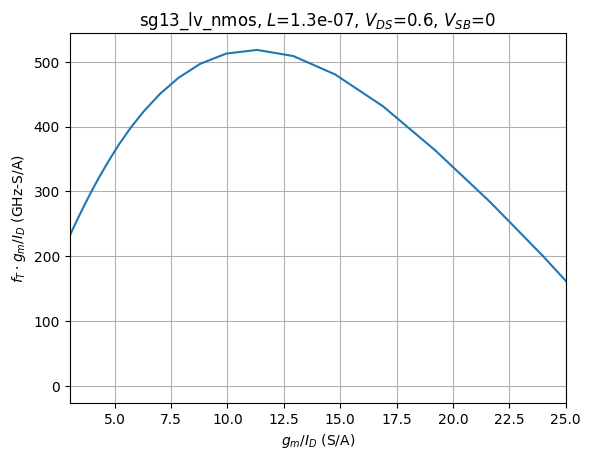

In [29]:
# plot product of gm/ID and fT versus gm/ID
plt.plot(gm_id1, gm_id1*ft1/1e9)
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$f_T\cdot g_m/I_D$ (GHz-S/A)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

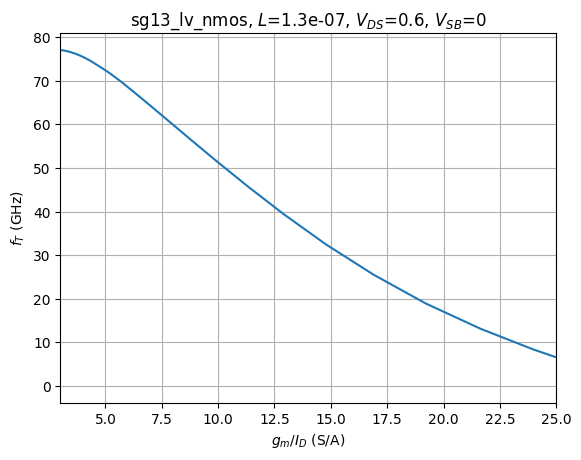

In [8]:
# plot fT versus gm/ID
plt.plot(gm_id1, ft1/1e9)
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$f_T$ (GHz)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

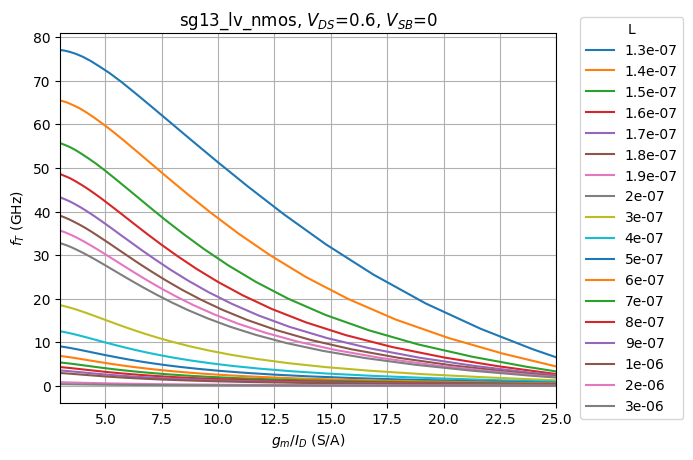

In [9]:
# plot fT versus gm/ID for all L
VDS2=0.6; VSB2=0
df2 = df.loc[ (df['vd'] == VDS2) & (df['vb'] == -VSB2)]
df2
gm_id2 = df2['gm'].values/df2['ids'].values
gm_id2 = np.reshape(gm_id2, (len(vgs), -1), order='F')
ft2 = df2['gm'].values/(df2['cgg'].values + df2['cgsol'].values + df2['cgdol'].values)/2/np.pi
ft2 = np.reshape(ft2, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.plot(gm_id2, ft2/1e9)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$f_T$ (GHz)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

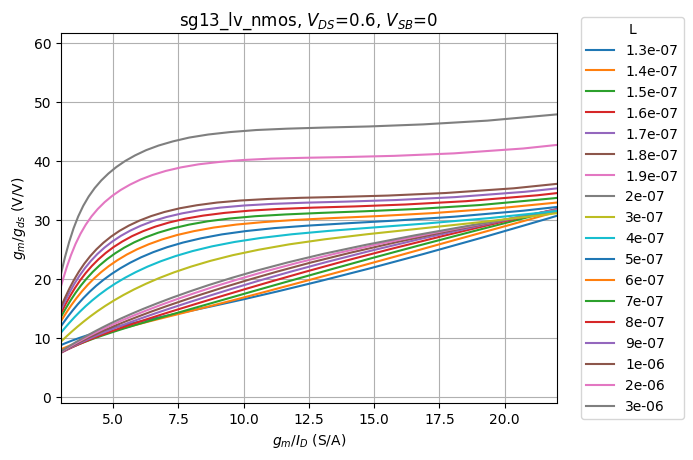

58.77817319098459


In [10]:
# plot gm/gds versus gm/ID for all L
gm_gds2 = df2['gm'].values/df2['gds'].values
gm_gds2 = np.reshape(gm_gds2, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.plot(gm_id2, gm_gds2)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 22)
#plt.ylim(3, 1000)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$g_m/g_{ds}$ (V/V)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()
print(np.amax(gm_gds2))

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\1558410223.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$J_D$ ($\mu$A/$\mu$m)')


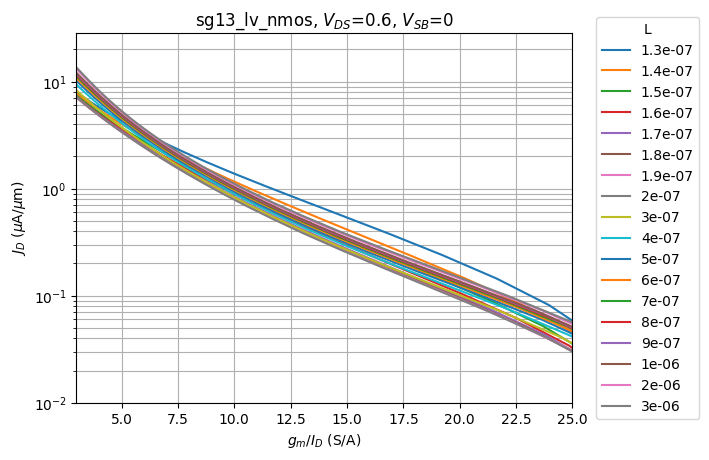

In [11]:
# plot jd versus gm/ID for all L
jd2 = df2['ids'].values/w[choice]/1e-6
jd2 = np.reshape(jd2, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.semilogy(gm_id2, jd2)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 25)
plt.ylim(1e-2, np.amax(jd2))
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$J_D$ ($\mu$A/$\mu$m)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\3064354070.py:11: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Thermal noise $\gamma$ factor')


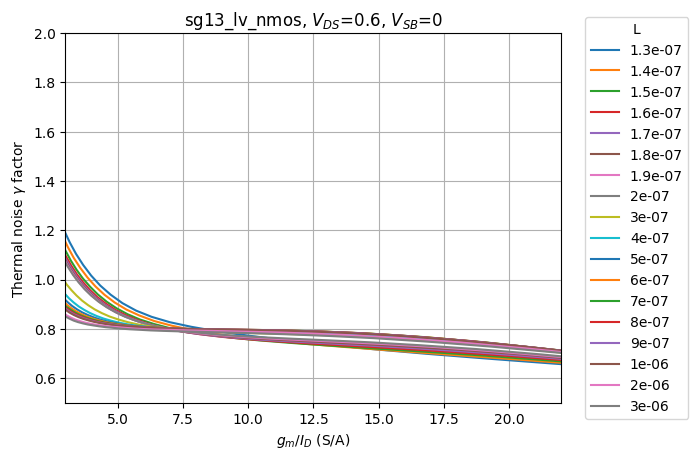

In [12]:
# plot gamma versus gm/ID for all L
gamma = df2['sid'].values / df2['gm'].values/4/300/1.38e-23
gamma = np.reshape(gamma, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.plot(gm_id2, gamma)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 22)
plt.ylim(0.5, 2)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('Thermal noise $\gamma$ factor')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\3171855049.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('1/f drain noise current at 1Hz ($nA/ \sqrt{Hz}$)')


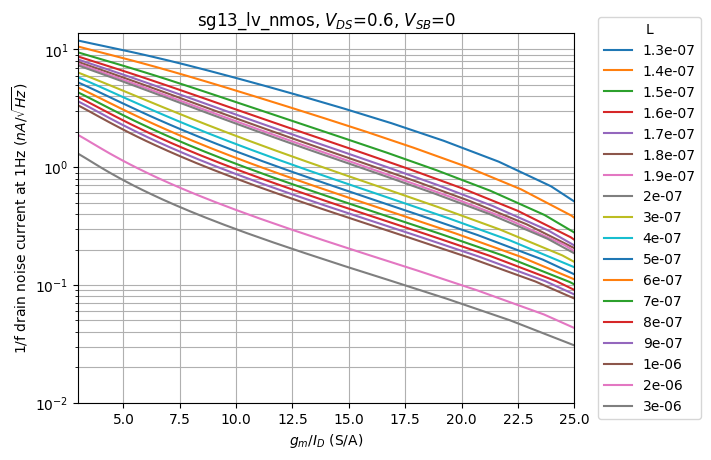

In [13]:
# plot flicker noise drain current at 1Hz versus gm/ID for all L
n1overf = df2['sfl'].values
n1overf = np.reshape(n1overf, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.semilogy(gm_id2, np.sqrt(n1overf)/1e-9)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 25)
plt.ylim(1e-2, np.amax(np.sqrt(n1overf)/1e-9))
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('1/f drain noise current at 1Hz ($nA/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\James\AppData\Local\Temp\ipykernel_34292\942213837.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('gate-referred 1/f noise at 1Hz ($\mu V/ \sqrt{Hz}$)')


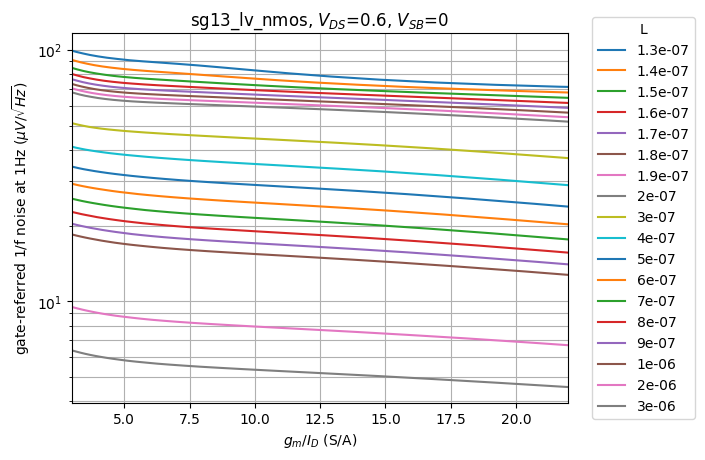

In [14]:
# plot gate-referred 1/f noise at 1Hz versus gm/ID for all L
n1overf_gate = df2['sfl'].values / df2['gm'].values**2
n1overf_gate = np.reshape(n1overf_gate, (len(vgs), -1), order='F')

fig, ax = plt.subplots()
ax.semilogy(gm_id2, np.sqrt(n1overf_gate)/1e-6)
ax.legend(loc='center right', bbox_to_anchor=(1.27, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 22)
plt.ylim(np.amin(np.sqrt(n1overf_gate)/1e-6), np.amax(np.sqrt(n1overf_gate)/1e-6))
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('gate-referred 1/f noise at 1Hz ($\mu V/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()